# Visualisation des clusters avec PCA

Ce notebook projette les variables RFM standardisées en 2 composantes principales et visualise les 4 segments finaux.

## Import des librairies et configuration des chemins

In [1]:
from pathlib import Path  # Construire des chemins robustes.
import os  # Créer les dossiers de sortie si besoin.
import pandas as pd  # Manipuler les tables.
import matplotlib.pyplot as plt  # Construire les visualisations.
from sklearn.decomposition import PCA  # Appliquer l'analyse en composantes principales.

PROJECT_ROOT = Path('.')  # Racine du projet.
PROCESSED_DIR = PROJECT_ROOT / 'data' / 'processed'  # Dossier des données préparées.
RESULTS_DIR = PROJECT_ROOT / 'data' / 'results'  # Dossier des résultats de clustering.
PLOTS_DIR = PROJECT_ROOT / 'plots'  # Dossier des graphiques.
os.makedirs(PLOTS_DIR, exist_ok=True)  # S'assurer que le dossier plots existe.

## Charger les features et les résultats de clustering

In [2]:
X_scaled_df = pd.read_csv(PROCESSED_DIR / 'X_scaled.csv')  # Charger la matrice RFM standardisée.
rfm = pd.read_csv(RESULTS_DIR / 'rfm_with_clusters.csv')  # Charger la table finale avec segments.

## Calculer la PCA et afficher la variance expliquée

In [3]:
pca = PCA(n_components=2)  # Initialiser la PCA à 2 composantes.
X_pca = pca.fit_transform(X_scaled_df)  # Ajuster et transformer les features.
print(f"Variance expliquée PC1 : {pca.explained_variance_ratio_[0]:.4f}")  # Afficher la part de PC1.
print(f"Variance expliquée PC2 : {pca.explained_variance_ratio_[1]:.4f}")  # Afficher la part de PC2.
print(f"Variance totale expliquée : {pca.explained_variance_ratio_.sum():.4f}")  # Afficher le cumul.

Variance expliquée PC1 : 0.5415
Variance expliquée PC2 : 0.2818
Variance totale expliquée : 0.8232


## Visualiser les 4 segments dans l'espace PCA

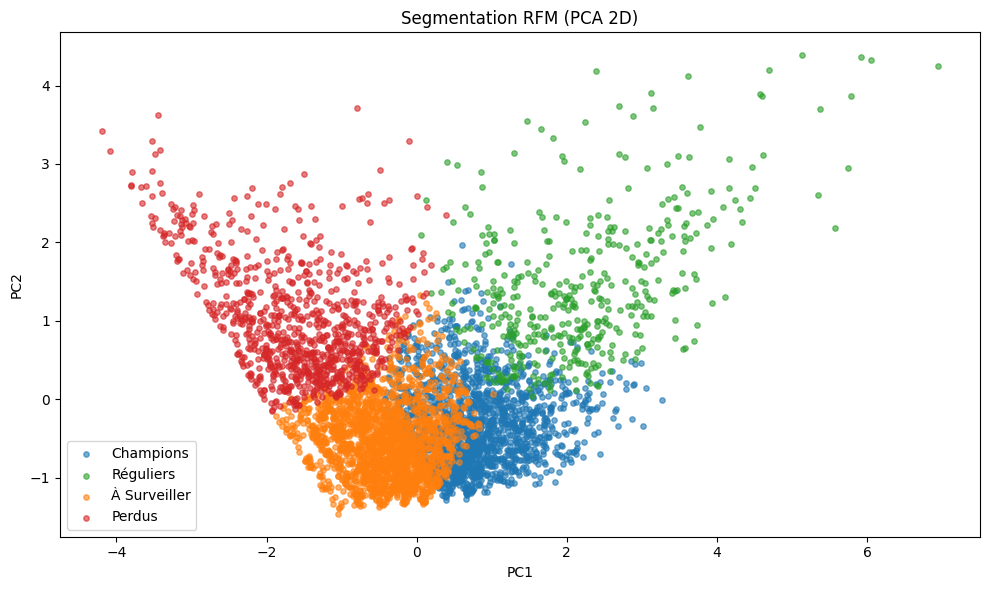

In [4]:
pca_df = pd.DataFrame({'PC1': X_pca[:, 0], 'PC2': X_pca[:, 1], 'SegmentRFM': rfm['SegmentRFM']})  # Construire la table PCA.

SEGMENT_COLORS = {  # Couleur fixe par segment pour une lecture cohérente.
    'Champions': '#1f77b4',
    'Réguliers': '#2ca02c',
    'À Surveiller': '#ff7f0e',
    'Perdus': '#d62728'
}
plt.figure(figsize=(10, 6))  # Initialiser la figure.
for seg in ['Champions', 'Réguliers', 'À Surveiller', 'Perdus']:  # Parcourir les 4 segments dans un ordre fixe.
    temp = pca_df[pca_df['SegmentRFM'] == seg]  # Sélectionner les points du segment courant.
    plt.scatter(temp['PC1'], temp['PC2'], alpha=0.6, label=seg, color=SEGMENT_COLORS[seg], s=15)  # Tracer les points.
plt.title('Segmentation RFM (PCA 2D)')  # Titre du graphique.
plt.xlabel('PC1')  # Label axe X.
plt.ylabel('PC2')  # Label axe Y.
plt.legend()  # Légende.
plt.tight_layout()  # Ajuster la mise en page.
plt.savefig(PLOTS_DIR / 'pca_segments.png', dpi=300)  # Sauvegarder le graphique.
plt.show()  # Afficher le graphique.

## Comparer le volume et le profil RFM par segment

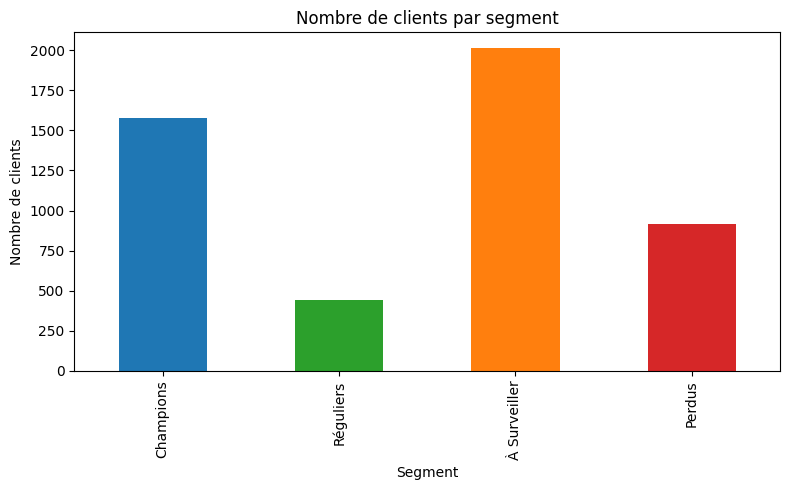

                 Recency  Frequency       Monetary
SegmentRFM                                        
Champions     147.934603   7.336508   49412.502488
Réguliers     162.861364   7.145455  199213.968745
À Surveiller  165.030348   3.636816   30128.596174
Perdus        621.646221   3.276013   28353.731209


In [5]:
counts = rfm['SegmentRFM'].value_counts().reindex(['Champions', 'Réguliers', 'À Surveiller', 'Perdus'])  # Compter les clients par segment.
plt.figure(figsize=(8, 5))  # Initialiser la figure.
counts.plot(kind='bar', color=[SEGMENT_COLORS[s] for s in counts.index])  # Tracer les barres de comptage.
plt.title('Nombre de clients par segment')  # Titre du graphique.
plt.xlabel('Segment')  # Label axe X.
plt.ylabel('Nombre de clients')  # Label axe Y.
plt.tight_layout()  # Ajuster la mise en page.
plt.savefig(PLOTS_DIR / 'segment_counts.png', dpi=300)  # Sauvegarder le graphique.
plt.show()  # Afficher le graphique.

segment_means = rfm.groupby('SegmentRFM')[['Recency', 'Frequency', 'Monetary']].mean().reindex(['Champions', 'Réguliers', 'À Surveiller', 'Perdus'])  # Moyennes RFM par segment.
print(segment_means)  # Afficher les moyennes RFM par segment.

## Sauvegarder la table PCA

In [6]:
pca_df.to_csv(PROCESSED_DIR / 'pca_visualization.csv', index=False)  # Sauvegarder les coordonnées PCA et segments.
print(f"Sauvegardé : {PROCESSED_DIR / 'pca_visualization.csv'}")  # Confirmer le chemin.

Sauvegardé : data/processed/pca_visualization.csv
